In [10]:
import pandas as pd

df = pd.read_csv("Final_Project.csv")

print(df.shape)
df.head()

(41, 11)


,ID,Date,Newspaper,Quote,Casue,Cause_Normalized,Effect,Effect_Normalized,Relation,Stance,URL
0,A01,1905-02-24,The Colfax gazette,It is recognized by all students of the subjec...,disregard of parental duty,Parental Neglect,Juvenile Crime,Juvenile Delinquency,CAUSES,SUPPORT,https://www.loc.gov/resource/sn88085460/1905-0...
1,A02,1908-04-02,Springfield weekly Republican,The society is now mainly concerned with the r...,shiftlessness,Shiftlessness,Parental Neglect,Parental Neglect,CAUSES,SUPPORT,https://www.loc.gov/resource/sn83020847/1908-0...
2,A03,1911-10-09,Evening star,Nearly every case of juvenile delinquency is c...,lack of proper food,Poverty,Juvenile Delinquent,Juvenile Delinquency,CAUSES,SUPPORT,https://www.loc.gov/resource/sn83045462/1911-1...
3,A04,1912-02-22,Iron County register,The juvenile delinquent is the logical and ine...,parental delinquency,Parental Neglect,Juvenile Delinquency,Juvenile Delinquency,CAUSES,SUPPORT,https://www.loc.gov/resource/sn84024283/1912-0...
4,A05,1912-12-23,Evening journal,Parental neglect and inefficiency are frequent...,parental neglect and inefficiency,Parental Neglect,Juvenile Delinquency,Juvenile Delinquency,CAUSES,SUPPORT,https://www.loc.gov/resource/sn85042354/1912-1...


In [11]:
causal_table = (
    df.groupby(
        ["Cause_Normalized", "Effect_Normalized", "Relation"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

causal_table

,Cause_Normalized,Effect_Normalized,Relation,count
3,Parental Neglect,Juvenile Delinquency,CAUSES,22
0,Broken Homes,Juvenile Delinquency,CAUSES,7
1,Comic Books,Juvenile Delinquency,ATTRIBUTED_TO,2
4,Parental Neglect,Juvenile Delinquency,CONTRIBUTES_TO,2
9,Working mothers,Juvenile Delinquency,CAUSES,2
6,Poverty,Juvenile Delinquency,CAUSES,2
5,Parental Neglect,Juvenile Delinquency,MIXED_CAUSATION,1
2,Moving Pictures,Juvenile Delinquency,CAUSES,1
7,Shiftlessness,Parental Neglect,CAUSES,1
8,Wartime Conditions,Parental Neglect,CAUSES,1


In [12]:
df.to_csv("final_project_clean.csv", index=False, encoding="utf-8-sig")
causal_table.to_csv("causal_table.csv", index=False, encoding="utf-8-sig")

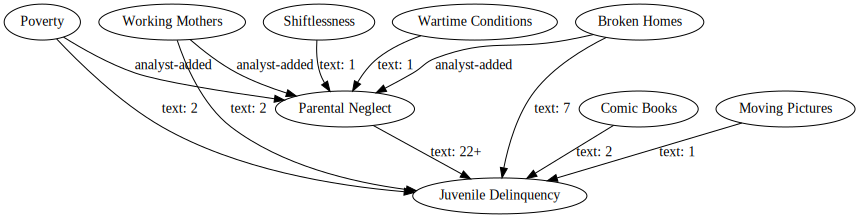

In [13]:
from graphviz import Digraph

g = Digraph("Causal_DAG", format="png")
g.attr(rankdir="TB")

# 주요 노드
nodes = [
    "Poverty",
    "Working Mothers",
    "Broken Homes",
    "Shiftlessness",
    "Wartime Conditions",
    "Parental Neglect",
    "Comic Books",
    "Moving Pictures",
    "Juvenile Delinquency"
]

for n in nodes:
    g.node(n)

# text-asserted edges
g.edge("Parental Neglect", "Juvenile Delinquency", label="text: 22+")
g.edge("Broken Homes", "Juvenile Delinquency", label="text: 7")
g.edge("Poverty", "Juvenile Delinquency", label="text: 2")
g.edge("Working Mothers", "Juvenile Delinquency", label="text: 2")
g.edge("Comic Books", "Juvenile Delinquency", label="text: 2")
g.edge("Moving Pictures", "Juvenile Delinquency", label="text: 1")
g.edge("Shiftlessness", "Parental Neglect", label="text: 1")
g.edge("Wartime Conditions", "Parental Neglect", label="text: 1")

# analyst-added edges
g.edge("Broken Homes", "Parental Neglect", label="analyst-added")
g.edge("Poverty", "Parental Neglect", label="analyst-added")
g.edge("Working Mothers", "Parental Neglect", label="analyst-added")

g.render("causal_dag", cleanup=True)
g

In [14]:
nodes = pd.DataFrame([
    ["Parental Neglect", "Treatment"],
    ["Juvenile Delinquency", "Outcome"],
    ["Broken Homes", "Confounder Candidate"],
    ["Poverty", "Confounder Candidate"],
    ["Working Mothers", "Upstream Cause"],
    ["Shiftlessness", "Upstream Cause"],
    ["Wartime Conditions", "Upstream Cause"],
    ["Comic Books", "Alternative Explanation"],
    ["Moving Pictures", "Alternative Explanation"]
], columns=["id", "type"])

nodes.to_csv(
    "nodes.csv",
    index=False,
    encoding="utf-8-sig"
)

nodes

,id,type
0,Parental Neglect,Treatment
1,Juvenile Delinquency,Outcome
2,Broken Homes,Confounder Candidate
3,Poverty,Confounder Candidate
4,Working Mothers,Upstream Cause
5,Shiftlessness,Upstream Cause
6,Wartime Conditions,Upstream Cause
7,Comic Books,Alternative Explanation
8,Moving Pictures,Alternative Explanation


In [15]:
nodes.to_csv(
    "nodes.csv",
    index=False,
    encoding="utf-8-sig"
)

In [18]:
import pandas as pd

edges_dag = pd.DataFrame([
    ["Shiftlessness", "Parental Neglect", "Text-supported", 1],
    ["Wartime Conditions", "Parental Neglect", "Text-supported", 1],
    ["Working Mothers", "Parental Neglect", "Analyst-added", 2],
    ["Poverty", "Parental Neglect", "Analyst-added", 2],
    ["Broken Homes", "Parental Neglect", "Analyst-added", 7],
    ["Parental Neglect", "Juvenile Delinquency", "Text-supported", 25],
    ["Broken Homes", "Juvenile Delinquency", "Text-supported", 7],
    ["Poverty", "Juvenile Delinquency", "Text-supported", 2],
    ["Comic Books", "Juvenile Delinquency", "Text-supported", 2],
    ["Moving Pictures", "Juvenile Delinquency", "Text-supported", 1],
], columns=["source", "target", "edge_type", "support"])

edges_dag

,source,target,edge_type,support
0,Shiftlessness,Parental Neglect,Text-supported,1
1,Wartime Conditions,Parental Neglect,Text-supported,1
2,Working Mothers,Parental Neglect,Analyst-added,2
3,Poverty,Parental Neglect,Analyst-added,2
4,Broken Homes,Parental Neglect,Analyst-added,7
5,Parental Neglect,Juvenile Delinquency,Text-supported,25
6,Broken Homes,Juvenile Delinquency,Text-supported,7
7,Poverty,Juvenile Delinquency,Text-supported,2
8,Comic Books,Juvenile Delinquency,Text-supported,2
9,Moving Pictures,Juvenile Delinquency,Text-supported,1


In [19]:
edges_dag.to_csv("edges.csv", index=False, encoding="utf-8-sig")

In [20]:
from google.colab import files
files.download("edges.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>